In [2]:
"""
Linear Mixed Effects Models: Between- vs. Within-Subject Decomposition
=======================================================================

Extends the cluster-permutation LMM script by decomposing each neural
predictor into:

  - between-subject component : subject mean of the predictor
                                 (stable trait — same value for every trial
                                  of a given subject × freq × region)
  - within-subject component  : trial deviation from that subject mean
                                 (moment-to-moment fluctuation)

Model formula (per freq × region):
  DV ~ neural_between + neural_within + (1 | subject) + (0 + C(subj_session) | subject)

Interpretation guide
---------------------
  Only neural_between significant  → effect is a between-subject trait
  Only neural_within  significant  → effect is a within-subject, trial-level mechanism
  Both significant                 → both levels contribute
  Neither significant              → no reliable effect at this freq

Everything else (cluster permutation logic, LMM structure, output format)
is identical to the original script.

Reference: Curran & Bauer (2011), Psych Methods — within-person centering
"""

import os
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from joblib import Parallel, delayed
from tqdm import tqdm
from typing import List, Tuple, Dict

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

DATA_FILE  = 'ALL_SUBJECTS_irasa_clean.csv'


COMPONENT_TYPES  = ['frac', 'osc']
PHASES           = ['encoding', 'retrieval']
DV_LIST          = [
    'SP_clustering_to_next', 'SP_clustering_from_prev',
    'T_clustering_to_next',  'T_clustering_from_prev'
]

N_PERMS          = 1000
CLUSTER_T_THRESH = 2.0
ALPHA            = 0.05
MIN_OBS          = 30
N_JOBS           = -1

OUTPUT_DIR = './LMM_results_between_within'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# LOAD DATA
# ============================================================================

print("=" * 80)
print("Loading data...")
print("=" * 80)

df  = pd.read_csv(DATA_FILE)


print(f"\nLoaded {len(df):,} rows")
print(f"Subjects   : {df['subject'].nunique()}")
print(f"Regions    : {df['region'].unique()}")
print(f"Frequencies: {sorted(df['freq_hz'].unique())}")

# ============================================================================
# DATA PREPARATION
# ============================================================================

df['subj_session'] = df['subject'] + '_' + df['session'].astype(str)

df_clean = df.dropna(subset=DV_LIST).copy()
print(f"\nRows after removing missing clustering scores: {len(df_clean):,}")
print(f"Unique subjects      : {df_clean['subject'].nunique()}")
print(f"Unique subj-sessions : {df_clean['subj_session'].nunique()}")

FREQUENCIES = sorted(df_clean['freq_hz'].unique())
REGIONS     = sorted(df_clean['region'].unique())


# ============================================================================
# BETWEEN / WITHIN DECOMPOSITION
# ============================================================================

def add_between_within(data: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    For a given neural column, compute per-subject mean (between) and
    trial-level deviation from that mean (within), grouped by
    subject × freq × region so the decomposition is frequency-specific.

    New columns:
      {col}_between  : subject mean  (one value per subject × freq × region)
      {col}_within   : trial deviation  (trial value minus subject mean)
    """
    data = data.copy()
    # Group by subject (within a given freq × region subset that is already
    # filtered before calling the LMM — but we add globally here so the
    # columns exist; the subset filtering happens in the main loop)
    subj_mean = (
        data.groupby('subject')[col]
        .transform('mean')
    )
    data[f'{col}_between'] = subj_mean
    data[f'{col}_within']  = data[col] - subj_mean
    return data


# Pre-compute decomposed columns for all neural predictors
print("\nComputing between/within decompositions...")
for phase in PHASES:
    for comp in COMPONENT_TYPES:
        col = f'{phase}_{comp}_ssl'
        if col in df_clean.columns:
            # Decompose within each freq × region combination
            # (subject means can differ slightly per freq — this is correct)
            df_clean[f'{col}_between'] = np.nan
            df_clean[f'{col}_within']  = np.nan

            for freq in FREQUENCIES:
                for region in REGIONS:
                    mask = (
                        (df_clean['freq_hz'] == freq) &
                        (df_clean['region']  == region)
                    )
                    sub = df_clean.loc[mask, ['subject', col]].copy()
                    if sub[col].isna().all():
                        continue
                    subj_mean = sub.groupby('subject')[col].transform('mean')
                    df_clean.loc[mask, f'{col}_between'] = subj_mean
                    df_clean.loc[mask, f'{col}_within']  = sub[col] - subj_mean

            pct_missing = df_clean[f'{col}_between'].isna().mean() * 100
            print(f"  {col}: decomposition done ({pct_missing:.1f}% missing)")

print("Decomposition complete.")

# ============================================================================
# HELPERS: LMM (observed)
# ============================================================================

def run_lmm_decomposed(data: pd.DataFrame,
                       dv: str,
                       between_col: str,
                       within_col: str) -> dict:
    """
    Fit LMM with both between and within predictors.
    Formula: DV ~ between + within + nested random effects

    Returns coefficients and stats for BOTH between and within.
    Falls back to simpler random structure if needed.
    """
    base_result = {
        'Coef_between': np.nan, 'SE_between': np.nan,
        't_between':    np.nan, 'p_between': np.nan,
        'Coef_within':  np.nan, 'SE_within': np.nan,
        't_within':     np.nan, 'p_within':  np.nan,
        'converged': False,
        'n_obs':      len(data),
        'n_subjects': data['subject'].nunique(),
        'n_sessions': data['subj_session'].nunique(),
        'model_note': 'failed',
    }

    formula = f'{dv} ~ {between_col} + {within_col}'

    for vc, note in [
        ({'subj_session': '0 + C(subj_session)'}, 'full'),
        (None, 'simple'),
    ]:
        try:
            kwargs = dict(
                formula=formula,
                data=data,
                groups=data['subject'],
                re_formula='~1'
            )
            if vc is not None:
                kwargs['vc_formula'] = vc

            result = smf.mixedlm(**kwargs).fit(
                method='powell', maxiter=1000, disp=False
            )

            out = base_result.copy()
            out.update({
                'Coef_between': float(result.params.get(between_col, np.nan)),
                'SE_between':   float(result.bse.get(between_col, np.nan)),
                't_between':    float(result.tvalues.get(between_col, np.nan)),
                'p_between':    float(result.pvalues.get(between_col, np.nan)),
                'Coef_within':  float(result.params.get(within_col, np.nan)),
                'SE_within':    float(result.bse.get(within_col, np.nan)),
                't_within':     float(result.tvalues.get(within_col, np.nan)),
                'p_within':     float(result.pvalues.get(within_col, np.nan)),
                'converged':    bool(result.converged),
                'model_note':   note,
            })
            return out

        except Exception:
            continue

    return base_result


# ============================================================================
# HELPERS: OLS t-stat for permutation (supports two predictors)
# ============================================================================

def ols_tstat_two_pred(y: np.ndarray,
                       x1: np.ndarray,
                       x2: np.ndarray) -> Tuple[float, float]:
    """
    Closed-form OLS t-statistics for both predictors in y ~ x1 + x2.
    Returns (t_x1, t_x2). Returns (NaN, NaN) if degenerate.
    """
    n = len(y)
    if n < MIN_OBS:
        return np.nan, np.nan
    try:
        X = np.column_stack([np.ones(n), x1, x2])
        XtX_inv = np.linalg.inv(X.T @ X)
        b = XtX_inv @ X.T @ y
        resid = y - X @ b
        s2 = (resid ** 2).sum() / (n - 3)
        se = np.sqrt(s2 * np.diag(XtX_inv))
        if se[1] < 1e-12 or se[2] < 1e-12:
            return np.nan, np.nan
        return float(b[1] / se[1]), float(b[2] / se[2])
    except np.linalg.LinAlgError:
        return np.nan, np.nan


# ============================================================================
# HELPERS: cluster detection
# ============================================================================

def find_clusters(t_values: np.ndarray,
                  threshold: float) -> List[Tuple[List[int], float]]:
    t = np.asarray(t_values, dtype=float)
    clusters = []
    for sign in (1, -1):
        mask   = (sign * t) > threshold
        padded = np.concatenate([[False], mask, [False]])
        changes = np.diff(padded.astype(int))
        starts = np.where(changes ==  1)[0]
        ends   = np.where(changes == -1)[0]
        for s, e in zip(starts, ends):
            idx  = list(range(s, e))
            mass = float(t[s:e].sum())
            clusters.append((idx, mass))
    return clusters


# ============================================================================
# PERMUTATION WORKER  (two predictors: between and within)
# ============================================================================

def _one_permutation_bw(
    freq_arrays  : List[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]],
    subject_list : np.ndarray,
    rng          : np.random.Generator,
) -> Tuple[float, float, float, float]:
    """
    Shuffle DV within each subject, recompute OLS t-stats for BOTH
    between and within predictors across frequencies.

    Returns: (max_pos_between, min_neg_between, max_pos_within, min_neg_within)
    """
    perm_t_between = []
    perm_t_within  = []

    for subj_ids, y_arr, x_between, x_within in freq_arrays:
        y_perm = y_arr.copy()
        for subj in subject_list:
            mask = subj_ids == subj
            if mask.sum() > 1:
                y_perm[mask] = rng.permutation(y_arr[mask])

        if len(y_perm) >= MIN_OBS:
            tb, tw = ols_tstat_two_pred(y_perm, x_between, x_within)
        else:
            tb, tw = np.nan, np.nan

        perm_t_between.append(tb)
        perm_t_within.append(tw)

    def _extremes(t_arr):
        t_filled = np.where(np.isnan(t_arr), 0.0, t_arr)
        clusters = find_clusters(t_filled, CLUSTER_T_THRESH)
        pos = [m for _, m in clusters if m > 0]
        neg = [m for _, m in clusters if m < 0]
        return (max(pos) if pos else 0.0,
                min(neg) if neg else 0.0)

    pb, nb = _extremes(np.array(perm_t_between))
    pw, nw = _extremes(np.array(perm_t_within))
    return pb, nb, pw, nw


# ============================================================================
# CLUSTER PERMUTATION TEST — between/within version
# ============================================================================

def cluster_permutation_test_bw(
    obs_t_between : np.ndarray,
    obs_t_within  : np.ndarray,
    freq_arrays   : List[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]],
    subject_list  : np.ndarray,
) -> Dict:
    """
    Run cluster permutation test separately for between and within predictors.
    Returns dict with per-frequency arrays for both components.
    """
    n_freqs = len(obs_t_between)
    defaults = {
        'cluster_id_between':     np.full(n_freqs, np.nan),
        'in_sig_cluster_between': np.zeros(n_freqs, dtype=bool),
        'cluster_p_between':      np.full(n_freqs, np.nan),
        'cluster_mass_between':   np.full(n_freqs, np.nan),
        'cluster_id_within':      np.full(n_freqs, np.nan),
        'in_sig_cluster_within':  np.zeros(n_freqs, dtype=bool),
        'cluster_p_within':       np.full(n_freqs, np.nan),
        'cluster_mass_within':    np.full(n_freqs, np.nan),
    }

    obs_t_b_filled = np.where(np.isnan(obs_t_between), 0.0, obs_t_between)
    obs_t_w_filled = np.where(np.isnan(obs_t_within),  0.0, obs_t_within)
    obs_clusters_b = find_clusters(obs_t_b_filled, CLUSTER_T_THRESH)
    obs_clusters_w = find_clusters(obs_t_w_filled, CLUSTER_T_THRESH)

    if not obs_clusters_b and not obs_clusters_w:
        defaults['n_obs_clusters_between'] = 0
        defaults['n_obs_clusters_within']  = 0
        return defaults

    # Run permutations
    seeds   = np.random.SeedSequence().spawn(N_PERMS)
    rngs    = [np.random.default_rng(s) for s in seeds]
    results = Parallel(n_jobs=N_JOBS, prefer='threads')(
        delayed(_one_permutation_bw)(freq_arrays, subject_list, rng)
        for rng in rngs
    )

    null_max_pos_b = np.array([r[0] for r in results])
    null_max_neg_b = np.array([r[1] for r in results])
    null_max_pos_w = np.array([r[2] for r in results])
    null_max_neg_w = np.array([r[3] for r in results])

    out = defaults.copy()

    def _assign(obs_clusters, null_pos, null_neg,
                id_arr, sig_arr, p_arr, mass_arr):
        for cid, (indices, mass) in enumerate(obs_clusters):
            p = float(np.mean(null_pos >= mass) if mass > 0
                      else np.mean(null_neg <= mass))
            sig = p < ALPHA
            for fi in indices:
                id_arr[fi]   = cid
                p_arr[fi]    = p
                mass_arr[fi] = mass
                sig_arr[fi]  = sig

    _assign(obs_clusters_b, null_max_pos_b, null_max_neg_b,
            out['cluster_id_between'], out['in_sig_cluster_between'],
            out['cluster_p_between'],  out['cluster_mass_between'])

    _assign(obs_clusters_w, null_max_pos_w, null_max_neg_w,
            out['cluster_id_within'], out['in_sig_cluster_within'],
            out['cluster_p_within'],  out['cluster_mass_within'])

    out['n_obs_clusters_between'] = len(obs_clusters_b)
    out['n_obs_clusters_within']  = len(obs_clusters_w)
    return out


# ============================================================================
# MAIN LOOP
# ============================================================================

print("\n" + "=" * 80)
print("Running Between/Within LMM + Cluster Permutation Analysis")
print(f"  N permutations   : {N_PERMS}")
print(f"  Cluster threshold: |t| > {CLUSTER_T_THRESH}")
print(f"  Alpha            : {ALPHA}")
print(f"  Parallel jobs    : {N_JOBS}")
print("=" * 80)

for dv in DV_LIST:
    print(f"\n{'=' * 80}")
    print(f"DV: {dv}")
    print(f"{'=' * 80}")

    all_results = []

    for phase in PHASES:
        for comp_type in COMPONENT_TYPES:

            neural_col      = f'{phase}_{comp_type}_ssl'
            between_col     = f'{neural_col}_between'
            within_col      = f'{neural_col}_within'

            print(f"\n  {phase}_{comp_type}")
            print(f"  {'─' * 70}")

            # ── Step 1: LMM observed stats (between + within) ──────────────
            lmm_rows = []
            for freq in FREQUENCIES:
                for region in REGIONS:
                    subset = df_clean[
                        (df_clean['freq_hz'] == freq) &
                        (df_clean['region']  == region)
                    ].dropna(subset=[neural_col, between_col,
                                     within_col, dv]).copy()

                    base_meta = {
                        'freq_hz': freq, 'region': region,
                        'phase': phase, 'component': comp_type,
                    }

                    if len(subset) < MIN_OBS:
                        row = base_meta.copy()
                        row.update({
                            'Coef_between': np.nan, 'SE_between': np.nan,
                            't_between': np.nan,    'p_between': np.nan,
                            'Coef_within':  np.nan, 'SE_within': np.nan,
                            't_within':  np.nan,    'p_within':  np.nan,
                            'converged': False,
                            'n_obs': len(subset),
                            'n_subjects': subset['subject'].nunique(),
                            'n_sessions': subset['subj_session'].nunique(),
                            'model_note': 'skipped_low_n',
                        })
                        lmm_rows.append(row)
                        continue

                    row = run_lmm_decomposed(
                        subset, dv, between_col, within_col
                    )
                    row.update(base_meta)
                    lmm_rows.append(row)

            lmm_df = pd.DataFrame(lmm_rows)

            # ── Step 2: Cluster permutation per region ─────────────────────
            for region in REGIONS:
                reg_lmm = (
                    lmm_df[lmm_df['region'] == region]
                    .copy()
                    .set_index('freq_hz')
                    .reindex(FREQUENCIES)
                )

                obs_t_b = reg_lmm['t_between'].values.astype(float)
                obs_t_w = reg_lmm['t_within'].values.astype(float)
                n_valid = int(
                    (~np.isnan(obs_t_b) | ~np.isnan(obs_t_w)).sum()
                )

                if n_valid < 2:
                    print(f"    ⚠ {region}: fewer than 2 valid t-values — skipping")
                    for sfx in ['between', 'within']:
                        lmm_df.loc[
                            lmm_df['region'] == region,
                            [f'cluster_id_{sfx}', f'in_sig_cluster_{sfx}',
                             f'cluster_p_{sfx}',  f'cluster_mass_{sfx}']
                        ] = np.nan
                    continue

                # Pre-extract arrays for OLS permutation
                freq_arrays = []
                for freq in FREQUENCIES:
                    sub = df_clean[
                        (df_clean['freq_hz'] == freq) &
                        (df_clean['region']  == region)
                    ].dropna(subset=[neural_col, between_col, within_col, dv])
                    freq_arrays.append((
                        sub['subject'].values,
                        sub[dv].values.astype(float),
                        sub[between_col].values.astype(float),
                        sub[within_col].values.astype(float),
                    ))

                subject_list = (
                    df_clean[df_clean['region'] == region]['subject'].unique()
                )

                print(f"    {region}: running {N_PERMS} permutations "
                      f"({n_valid} valid freqs, {len(subject_list)} subjects)...")

                perm_result = cluster_permutation_test_bw(
                    obs_t_b, obs_t_w, freq_arrays, subject_list
                )

                for fi, freq in enumerate(FREQUENCIES):
                    mask = (
                        (lmm_df['region'] == region) &
                        (lmm_df['freq_hz'] == freq)
                    )
                    for sfx in ['between', 'within']:
                        lmm_df.loc[mask, f'cluster_id_{sfx}']     = perm_result[f'cluster_id_{sfx}'][fi]
                        lmm_df.loc[mask, f'in_sig_cluster_{sfx}'] = perm_result[f'in_sig_cluster_{sfx}'][fi]
                        lmm_df.loc[mask, f'cluster_p_{sfx}']      = perm_result[f'cluster_p_{sfx}'][fi]
                        lmm_df.loc[mask, f'cluster_mass_{sfx}']   = perm_result[f'cluster_mass_{sfx}'][fi]

                nb = int(perm_result['n_obs_clusters_between'])
                nw = int(perm_result['n_obs_clusters_within'])
                sb = int(perm_result['in_sig_cluster_between'].sum())
                sw = int(perm_result['in_sig_cluster_within'].sum())
                print(f"    {region}: between → {nb} cluster(s), {sb} sig freq(s) | "
                      f"within → {nw} cluster(s), {sw} sig freq(s)")

            all_results.append(lmm_df)

    # ── Save and summarize ─────────────────────────────────────────────────
    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)
        final_df = final_df.sort_values(
            ['phase', 'component', 'region', 'freq_hz']
        )

        for sfx in ['between', 'within']:
            final_df[f'sig_uncorrected_{sfx}'] = final_df[f'p_{sfx}'] < 0.05
            final_df[f'sig_cluster_{sfx}']     = final_df[
                f'in_sig_cluster_{sfx}'
            ].fillna(False)

        out_file = os.path.join(OUTPUT_DIR, f'LMM_bw_{dv}.csv')
        final_df.to_csv(out_file, index=False)
        print(f"\n  ✓ Saved: {out_file}")

        # ── Summary table ─────────────────────────────────────────────────
        print(f"\n  {'─' * 70}")
        print(f"  SIGNIFICANT CLUSTERS SUMMARY")
        print(f"  {'─' * 70}")

        for sfx, label in [('between', 'BETWEEN-subject'), ('within', 'WITHIN-subject')]:
            sig_mask = final_df[f'sig_cluster_{sfx}']
            if sig_mask.any():
                print(f"\n  [{label}] — cluster-corrected:")
                summary = (
                    final_df[sig_mask]
                    .groupby(['phase', 'component', 'region',
                              f'cluster_id_{sfx}'])
                    .agg(
                        freq_min  = ('freq_hz', 'min'),
                        freq_max  = ('freq_hz', 'max'),
                        n_freqs   = ('freq_hz', 'count'),
                        cluster_p = (f'cluster_p_{sfx}', 'first'),
                        mass      = (f'cluster_mass_{sfx}', 'first'),
                        mean_t    = (f't_{sfx}', 'mean'),
                        mean_coef = (f'Coef_{sfx}', 'mean'),
                    )
                    .reset_index()
                )
                print(summary.to_string(index=False))
            else:
                print(f"\n  [{label}]: no significant clusters.")

        # ── Key diagnostic: did between and within effects dissociate? ─────
        print(f"\n  {'─' * 70}")
        print(f"  DISSOCIATION DIAGNOSTIC")
        print(f"  {'─' * 70}")
        n_b_only = (
            final_df['sig_cluster_between'] & ~final_df['sig_cluster_within']
        ).sum()
        n_w_only = (
            ~final_df['sig_cluster_between'] & final_df['sig_cluster_within']
        ).sum()
        n_both   = (
            final_df['sig_cluster_between'] & final_df['sig_cluster_within']
        ).sum()
        print(f"  Freq×region cells significant for BETWEEN only : {n_b_only}")
        print(f"  Freq×region cells significant for WITHIN only  : {n_w_only}")
        print(f"  Freq×region cells significant for BOTH         : {n_both}")

        if n_b_only > 0 and n_w_only == 0 and n_both == 0:
            print("\n  ➜ CONCLUSION: Effect is BETWEEN-SUBJECT only.")
            print("    Neural predictor reflects individual differences,")
            print("    not trial-level fluctuations.")
        elif n_w_only > 0 and n_b_only == 0 and n_both == 0:
            print("\n  ➜ CONCLUSION: Effect is WITHIN-SUBJECT only.")
            print("    Neural predictor reflects trial-level mechanism.")
        elif n_both > 0:
            print("\n  ➜ CONCLUSION: Effect present at BOTH levels.")
        else:
            print("\n  ➜ CONCLUSION: No cluster-corrected effects at either level.")

# ============================================================================
# DONE
# ============================================================================

print("\n" + "=" * 80)
print("✓ BETWEEN/WITHIN DECOMPOSITION ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nOutputs in: {OUTPUT_DIR}/")
for dv in DV_LIST:
    print(f"  LMM_bw_{dv}.csv")
print("""
Column guide:
  Coef_between / SE_between / t_between / p_between
      → LMM stats for the between-subject (subject mean) predictor

  Coef_within / SE_within / t_within / p_within
      → LMM stats for the within-subject (trial deviation) predictor

  cluster_id_between / in_sig_cluster_between / cluster_p_between / cluster_mass_between
      → Cluster permutation results for between component

  cluster_id_within / in_sig_cluster_within / cluster_p_within / cluster_mass_within
      → Cluster permutation results for within component

  sig_uncorrected_between / sig_uncorrected_within  → p < 0.05 uncorrected
  sig_cluster_between / sig_cluster_within          → cluster-corrected significance

Interpretation:
  Only between significant  → trait-level effect (individual differences)
  Only within  significant  → trial-level mechanism
  Both significant          → multi-level effect
  Neither                   → no reliable effect
""")

Loading data...

Loaded 27,162 rows
Subjects   : 26
Regions    : ['RHP' 'LHP']
Frequencies: [3.0, 3.74, 4.67, 5.82, 7.26, 9.05, 11.28, 14.07, 17.55, 21.88, 27.29, 34.03, 42.44, 52.92, 66.0, 82.31, 102.64, 128.0]

Rows after removing missing clustering scores: 16,434
Unique subjects      : 26
Unique subj-sessions : 64

Computing between/within decompositions...
  encoding_frac_ssl: decomposition done (0.0% missing)
  encoding_osc_ssl: decomposition done (0.0% missing)
  retrieval_frac_ssl: decomposition done (0.0% missing)
  retrieval_osc_ssl: decomposition done (0.0% missing)
Decomposition complete.

Running Between/Within LMM + Cluster Permutation Analysis
  N permutations   : 1000
  Cluster threshold: |t| > 2.0
  Alpha            : 0.05
  Parallel jobs    : -1

DV: SP_clustering_to_next

  encoding_frac
  ──────────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

In [2]:
"""
LME Analysis: Retrieval Fractal Power ~ Clustering Type × Direction
====================================================================
DV:  retrieval_frac_ssl (per freq)
IVs: clustering_type (SP / T)  ×  clustering_direction (to_next / from_prev)
RE:  subject (intercept) + session nested in subject (variance component)

Output
------
  lme_fractal_clustering_results.csv   — full coefficient table
  lme_fractal_clustering_plot.svg      — summary figure (3 panels × 18 freqs)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.regression.mixed_linear_model import MixedLM
import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
 # adjust if needed
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── palette (deep Seaborn-inspired) ────────────────────────────────────────
C_NS       = '#5B8DB8'   # blue  – not significant
C_UNCORR   = '#E07B54'   # warm orange-red – uncorrected p < .05
C_FDR      = '#B22222'   # dark red – FDR p < .05  (unused here but kept for consistency)
C_ZERO     = '#888888'

# ── freq labels ────────────────────────────────────────────────────────────
IRASA_FREQS = np.round(np.logspace(np.log10(3), np.log10(128), 18), 2)

# ============================================================
# 1. LOAD & RESHAPE
# ============================================================
print("Loading data...")

print(f"  Raw rows: {len(df):,}   subjects: {df['subject'].nunique()}")

# Keep retrieval rows only and drop NaN DV
df = df.dropna(subset=['retrieval_frac_ssl'])

# Melt the 4 clustering columns into clustering_score + two factor columns
id_vars = [c for c in df.columns if c not in
           ['SP_clustering_from_prev', 'SP_clustering_to_next',
            'T_clustering_from_prev',  'T_clustering_to_next']]

df_long = df.melt(
    id_vars=id_vars,
    value_vars=['SP_clustering_from_prev', 'SP_clustering_to_next',
                'T_clustering_from_prev',  'T_clustering_to_next'],
    var_name='clustering_label',
    value_name='clustering_score'
)

# Parse clustering_label → type & direction
df_long['clustering_type']      = df_long['clustering_label'].apply(
    lambda x: 'SP' if x.startswith('SP') else 'T')
df_long['clustering_direction'] = df_long['clustering_label'].apply(
    lambda x: 'to_next' if 'to_next' in x else 'from_prev')

# Drop rows with NaN clustering score
df_long = df_long.dropna(subset=['clustering_score'])

# Subject × session identifier for nested RE
df_long['subj_sess'] = df_long['subject'].astype(str) + '_' + df_long['session'].astype(str)

# Encode factors as dummy codes (reference: SP, from_prev)
df_long['type_T']         = (df_long['clustering_type']      == 'T').astype(float)
df_long['dir_to_next']    = (df_long['clustering_direction'] == 'to_next').astype(float)
df_long['type_x_dir']     = df_long['type_T'] * df_long['dir_to_next']

print(f"  Long-format rows: {len(df_long):,}")
print(f"  Clustering type counts:\n{df_long['clustering_type'].value_counts()}")
print(f"  Direction counts:\n{df_long['clustering_direction'].value_counts()}")

# ============================================================
# 2. FIT LME PER FREQUENCY
# ============================================================
print("\nFitting LME models per frequency...")

results = []

for freq_idx, freq_hz in enumerate(IRASA_FREQS):
    fd = df_long[df_long['freq_hz'] == freq_hz].copy()

    if len(fd) < 30:
        print(f"  freq {freq_hz:6.2f} Hz — skipped (n={len(fd)})")
        continue

    # z-score DV within this freq slice
    dv_mean = fd['retrieval_frac_ssl'].mean()
    dv_std  = fd['retrieval_frac_ssl'].std()
    if dv_std == 0:
        continue
    fd['dv_z'] = (fd['retrieval_frac_ssl'] - dv_mean) / dv_std

    # z-score clustering score
    cs_mean = fd['clustering_score'].mean()
    cs_std  = fd['clustering_score'].std()
    if cs_std == 0:
        continue
    fd['cs_z'] = (fd['clustering_score'] - cs_mean) / cs_std

    try:
        # from_formula supports vc_formula in statsmodels >= 0.9
        # RE: random intercept per subject + session-within-subject VC
        model = MixedLM.from_formula(
            formula='dv_z ~ cs_z + type_T + dir_to_next + type_x_dir',
            data=fd,
            groups='subject',
            vc_formula={'subj_sess': '0 + C(subj_sess)'}
        )
        fit = model.fit(reml=True, method='lbfgs', maxiter=200)

        for term in ['cs_z', 'type_T', 'dir_to_next', 'type_x_dir']:
            if term not in fit.params.index:
                print(f"    WARNING: term '{term}' not in model params: {list(fit.params.index)}")
                continue
            ci = fit.conf_int()
            results.append({
                'freq_hz':   freq_hz,
                'freq_idx':  freq_idx,
                'term':      term,
                'coef':      fit.params[term],
                'se':        fit.bse[term],
                'z':         fit.tvalues[term],
                'p':         fit.pvalues[term],
                'ci_lo':     ci.loc[term, 0],
                'ci_hi':     ci.loc[term, 1],
                'n_obs':     int(fit.nobs),
            })

        print(f"  freq {freq_hz:6.2f} Hz — OK  (n={int(fit.nobs):,})")

    except Exception as e:
        import traceback
        print(f"  freq {freq_hz:6.2f} Hz — FAILED: {e}")
        traceback.print_exc()
        continue

res_df = pd.DataFrame(results)
res_csv = os.path.join(OUTPUT_DIR, 'lme_fractal_clustering_results.csv')
res_df.to_csv(res_csv, index=False)
print(f"\nResults saved: {res_csv}  ({len(res_df)} rows)")

# ============================================================
# 3. PLOT
# ============================================================
print("\nGenerating figure...")

if len(res_df) == 0:
    raise RuntimeError(
        "res_df is empty — all LME fits failed. "
        "Check the traceback above for the root cause."
    )

# term → panel mapping
PANELS = [
    ('type_T',      'Main Effect: Clustering Type\n(T > SP)',          'Type'),
    ('dir_to_next', 'Main Effect: Direction\n(to_next > from_prev)',    'Direction'),
    ('type_x_dir',  'Interaction\n(Type × Direction)',                  'Type × Dir'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.patch.set_facecolor('#FAFAFA')

freq_arr = np.array(sorted(res_df['freq_hz'].unique()))
x_pos    = np.arange(len(freq_arr))

# shared x-tick labels (every other freq for readability)
xtick_labels = [f'{f:.1f}' if i % 2 == 0 else '' for i, f in enumerate(freq_arr)]

for ax, (term, title, short_label) in zip(axes, PANELS):
    sub = res_df[res_df['term'] == term].set_index('freq_hz')

    for xi, fhz in enumerate(freq_arr):
        if fhz not in sub.index:
            continue
        row   = sub.loc[fhz]
        coef  = row['coef']
        ci_lo = row['ci_lo']
        ci_hi = row['ci_hi']
        p     = row['p']

        color = C_UNCORR if p < 0.05 else C_NS
        zorder = 3 if p < 0.05 else 2
        alpha  = 1.0 if p < 0.05 else 0.65

        # error bar (CI)
        ax.plot([xi, xi], [ci_lo, ci_hi],
                color=color, lw=1.4, alpha=alpha, zorder=zorder)
        # point
        ax.scatter(xi, coef, color=color, s=55, zorder=zorder+1,
                   alpha=alpha, edgecolors='white', linewidths=0.5)

    # zero reference
    ax.axhline(0, color=C_ZERO, lw=0.9, ls='--', zorder=1)

    # significance shading bands
    for xi, fhz in enumerate(freq_arr):
        if fhz not in sub.index:
            continue
        if sub.loc[fhz, 'p'] < 0.05:
            ax.axvspan(xi - 0.45, xi + 0.45, color=C_UNCORR, alpha=0.08, zorder=0)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('β (z-scored)', fontsize=9)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_facecolor('#F5F5F5')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', labelsize=8)

    # annotation: n sig freqs
    n_sig = (sub['p'] < 0.05).sum()
    ax.text(0.98, 0.02, f'{n_sig}/{len(sub)} freqs p<.05',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color=C_UNCORR if n_sig > 0 else C_NS)

# shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_NS,
           markersize=8, label='n.s.'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_UNCORR,
           markersize=8, label='p < .05 (uncorrected)'),
]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=2, fontsize=9, frameon=True,
           bbox_to_anchor=(0.5, 1.01))

fig.suptitle(
    'Retrieval Fractal Power ~ Clustering Type × Direction\n'
    '(LME, z-scored within freq; RE: subject + session|subject)',
    fontsize=12, y=1.07
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
out_fig = os.path.join(OUTPUT_DIR, 'lme_fractal_clustering_plot.svg')
fig.savefig(out_fig, bbox_inches='tight', dpi=150)
print(f"Figure saved: {out_fig}")

# ── quick console summary ──────────────────────────────────────────────────
print("\n── Significant effects (p < .05, no correction) ──")
sig = res_df[res_df['p'] < 0.05][['freq_hz', 'term', 'coef', 'se', 'p']]
print(sig.to_string(index=False) if len(sig) else "  None")
print("\nDone.")

Loading data...
  Raw rows: 28,836   subjects: 36
  Long-format rows: 92,016
  Clustering type counts:
SP    46008
T     46008
Name: clustering_type, dtype: int64
  Direction counts:
from_prev    46008
to_next      46008
Name: clustering_direction, dtype: int64

Fitting LME models per frequency...
  freq   3.00 Hz — OK  (n=5,112)
  freq   3.74 Hz — OK  (n=5,112)
  freq   4.67 Hz — OK  (n=5,112)
  freq   5.82 Hz — OK  (n=5,112)
  freq   7.26 Hz — OK  (n=5,112)
  freq   9.05 Hz — OK  (n=5,112)
  freq  11.28 Hz — OK  (n=5,112)
  freq  14.07 Hz — OK  (n=5,112)
  freq  17.55 Hz — OK  (n=5,112)
  freq  21.88 Hz — OK  (n=5,112)
  freq  27.29 Hz — OK  (n=5,112)
  freq  34.03 Hz — OK  (n=5,112)
  freq  42.44 Hz — OK  (n=5,112)
  freq  52.92 Hz — OK  (n=5,112)
  freq  66.00 Hz — OK  (n=5,112)
  freq  82.31 Hz — OK  (n=5,112)
  freq 102.64 Hz — OK  (n=5,112)
  freq 128.00 Hz — OK  (n=5,112)

Results saved: ./lme_fractal_clustering_results.csv  (72 rows)

Generating figure...
Figure saved: ./lme_f

In [4]:
"""
Frequency Band Analysis: Effect of Oscillatory & Fractal Power on Clustering
=============================================================================

Averages neural predictors within canonical frequency bands:
  theta  :  2–5  Hz
  alpha  :  5–12 Hz
  beta   : 12–40 Hz
  gamma  : 40+   Hz

DVs (from_prev only):
  SP_clustering_from_prev
  T_clustering_from_prev

Predictors (osc and frac separately):
  encoding_osc_ssl,  encoding_frac_ssl
  retrieval_osc_ssl, retrieval_frac_ssl

Models:
  1. LMM with between-subject (subject mean) and within-subject (trial deviation)
     decomposition, one model per band × region × DV × phase × component.

Outputs:
  band_results.csv   — full LMM results
  band_summary.csv   — significant effects table
  band_analysis.txt  — console-style summary
"""

import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from itertools import product

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

DATA_FILE = 'ALL_SUBJECTS_irasa_clean.csv'

BANDS = {
    'theta': (2,   5),
    'alpha': (5,  12),
    'beta' : (12, 40),
    'gamma': (40, np.inf),
}

DVS    = ['SP_clustering_from_prev', 'T_clustering_from_prev']
PHASES = ['encoding', 'retrieval']
COMPS  = ['osc', 'frac']

MIN_OBS = 15   # minimum rows to attempt a model

# ============================================================================
# LOAD & CLEAN
# ============================================================================

df = pd.read_csv(DATA_FILE)

# Replace sentinel -999 with NaN throughout
df.replace(-999, np.nan, inplace=True)

print(f"Loaded {len(df):,} rows | {df['subject'].nunique()} subjects | "
      f"regions: {sorted(df['region'].unique())}")
print(f"freq_hz range: {df['freq_hz'].min():.1f} – {df['freq_hz'].max():.1f} Hz\n")

# ============================================================================
# BAND ASSIGNMENT
# ============================================================================

def assign_band(freq):
    for band, (lo, hi) in BANDS.items():
        if lo <= freq < hi:
            return band
    return None

df['band'] = df['freq_hz'].apply(assign_band)
print("Rows per band:")
print(df['band'].value_counts().sort_index())
print()

# ============================================================================
# BAND-AVERAGE NEURAL PREDICTORS
# ============================================================================
# Average across frequencies within each band, per row-group defined by
# (subject, session, trial, recalled_word, region)

GROUP_KEYS = ['subject', 'session', 'trial', 'recalled_word', 'region']
NEURAL_COLS = [f'{ph}_{comp}_ssl'
               for ph, comp in product(PHASES, COMPS)]

# Keep one row per unique (subject,session,trial,recalled_word,region,band)
# by averaging neural columns and taking the first value for DVs
dv_cols = DVS + ['recall_stim', 'encoding_stim']

agg_dict = {col: 'mean' for col in NEURAL_COLS if col in df.columns}
agg_dict.update({col: 'first' for col in dv_cols if col in df.columns})

df_band = (
    df.dropna(subset=['band'])
    .groupby(GROUP_KEYS + ['band'], as_index=False)
    .agg(agg_dict)
)

df_band['subj_session'] = (
    df_band['subject'] + '_' + df_band['session'].astype(str)
)

print(f"Band-averaged dataframe: {len(df_band):,} rows\n")

# ============================================================================
# BETWEEN / WITHIN DECOMPOSITION
# ============================================================================

def decompose(data, col):
    """Add {col}_between (subject mean) and {col}_within (trial deviation)."""
    data = data.copy()
    subj_mean = data.groupby('subject')[col].transform('mean')
    data[f'{col}_between'] = subj_mean
    data[f'{col}_within']  = data[col] - subj_mean
    return data

# ============================================================================
# LMM FITTING
# ============================================================================

def run_lmm(data, dv, between_col, within_col):
    """
    Fit: dv ~ between + within + (1|subject)
    Falls back to simpler random structure if needed.
    Returns dict with stats for both between and within.
    """
    result = {k: np.nan for k in [
        'Coef_between', 'SE_between', 't_between', 'p_between',
        'Coef_within',  'SE_within',  't_within',  'p_within',
    ]}
    result.update({
        'n_obs':      len(data),
        'n_subjects': data['subject'].nunique(),
        'converged':  False,
        'note':       'failed',
    })

    formula = f'{dv} ~ {between_col} + {within_col}'

    for vc, note in [
        ({'subj_session': '0 + C(subj_session)'}, 'full_RE'),
        (None, 'simple_RE'),
    ]:
        try:
            kwargs = dict(
                formula=formula,
                data=data,
                groups=data['subject'],
                re_formula='~1',
            )
            if vc:
                kwargs['vc_formula'] = vc

            fit = smf.mixedlm(**kwargs).fit(
                method='powell', maxiter=1000, disp=False
            )

            result.update({
                'Coef_between': float(fit.params.get(between_col, np.nan)),
                'SE_between':   float(fit.bse.get(between_col, np.nan)),
                't_between':    float(fit.tvalues.get(between_col, np.nan)),
                'p_between':    float(fit.pvalues.get(between_col, np.nan)),
                'Coef_within':  float(fit.params.get(within_col, np.nan)),
                'SE_within':    float(fit.bse.get(within_col, np.nan)),
                't_within':     float(fit.tvalues.get(within_col, np.nan)),
                'p_within':     float(fit.pvalues.get(within_col, np.nan)),
                'converged':    bool(fit.converged),
                'note':         note,
            })
            return result
        except Exception:
            continue

    return result

# ============================================================================
# MAIN ANALYSIS LOOP
# ============================================================================

rows = []

for dv in DVS:
    for phase in PHASES:
        for comp in COMPS:
            neural_col  = f'{phase}_{comp}_ssl'
            between_col = f'{neural_col}_between'
            within_col  = f'{neural_col}_within'

            for band in BANDS:
                for region in sorted(df_band['region'].unique()):

                    sub = df_band[
                        (df_band['band']   == band) &
                        (df_band['region'] == region)
                    ].dropna(subset=[neural_col, dv]).copy()

                    meta = {
                        'dv': dv, 'phase': phase, 'component': comp,
                        'band': band, 'region': region,
                    }

                    if len(sub) < MIN_OBS or sub['subject'].nunique() < 2:
                        meta.update({
                            'Coef_between': np.nan, 'SE_between': np.nan,
                            't_between': np.nan,    'p_between': np.nan,
                            'Coef_within': np.nan,  'SE_within': np.nan,
                            't_within': np.nan,     'p_within': np.nan,
                            'n_obs': len(sub),
                            'n_subjects': sub['subject'].nunique(),
                            'converged': False, 'note': 'skipped',
                        })
                        rows.append(meta)
                        continue

                    # Decompose within this specific subset
                    sub = decompose(sub, neural_col)

                    res = run_lmm(sub, dv, between_col, within_col)
                    res.update(meta)
                    rows.append(res)

results = pd.DataFrame(rows)

# Significance flags (uncorrected p < 0.05)
results['sig_between'] = results['p_between'] < 0.05
results['sig_within']  = results['p_within']  < 0.05

#

Loaded 28,836 rows | 36 subjects | regions: ['LHP', 'RHP']
freq_hz range: 3.0 – 128.0 Hz

Rows per band:
alpha    6408
beta     8010
gamma    9612
theta    4806
Name: band, dtype: int64

Band-averaged dataframe: 6,408 rows



In [5]:

# SAVE
# ============================================================================



# Summary of significant effects
sig = results[results['sig_between'] | results['sig_within']].copy()
sig_cols = ['dv', 'phase', 'component', 'band', 'region',
            't_between', 'p_between', 't_within', 'p_within',
            'sig_between', 'sig_within', 'n_obs', 'n_subjects', 'note']


# ============================================================================
# PRINT SUMMARY
# ============================================================================

BAND_ORDER = ['theta', 'alpha', 'beta', 'gamma']
lines = []
L = lines.append

L("=" * 90)
L("FREQUENCY BAND ANALYSIS — Between- and Within-Subject Effects on Clustering")
L("  DVs      : SP_clustering_from_prev | T_clustering_from_prev")
L("  Predictors: osc_ssl and frac_ssl (separately) × encoding / retrieval")
L("  Bands     : theta 2–5 Hz | alpha 5–12 Hz | beta 12–40 Hz | gamma 40+ Hz")
L("  Significance: uncorrected p < 0.05  (t-statistics from LMM)")
L("=" * 90)

for dv in DVS:
    L(f"\n{'━' * 90}")
    L(f"  DV: {dv}")
    L(f"{'━' * 90}")

    for phase in PHASES:
        for comp in COMPS:
            L(f"\n  [{phase.upper()} | {comp.upper()}]")
            L(f"  {'─' * 80}")
            L(f"  {'Band':<8} {'Region':<8} {'t_between':>11} {'p_between':>11} "
              f"{'t_within':>10} {'p_within':>10} {'n_obs':>7} {'Level':>22}")
            L(f"  {'─' * 80}")

            sub = results[
                (results['dv']        == dv) &
                (results['phase']     == phase) &
                (results['component'] == comp)
            ]

            for band in BAND_ORDER:
                for region in sorted(sub['region'].unique()):
                    row = sub[(sub['band'] == band) & (sub['region'] == region)]
                    if row.empty:
                        continue
                    row = row.iloc[0]

                    if row['note'] == 'skipped':
                        L(f"  {band:<8} {region:<8} {'(skipped – insufficient data)':>55}")
                        continue

                    tb  = f"{row['t_between']:+.3f}" if not np.isnan(row['t_between']) else '  NaN'
                    pb  = f"{row['p_between']:.3f}"  if not np.isnan(row['p_between']) else '  NaN'
                    tw  = f"{row['t_within']:+.3f}"  if not np.isnan(row['t_within'])  else '  NaN'
                    pw  = f"{row['p_within']:.3f}"   if not np.isnan(row['p_within'])  else '  NaN'
                    n   = str(int(row['n_obs']))

                    sb  = '**' if row['sig_between'] else '  '
                    sw  = '**' if row['sig_within']  else '  '

                    if row['sig_between'] and row['sig_within']:
                        level = 'BOTH (between & within)'
                    elif row['sig_between']:
                        level = 'BETWEEN-subject only'
                    elif row['sig_within']:
                        level = 'WITHIN-subject only'
                    else:
                        level = '–'

                    L(f"  {band:<8} {region:<8} {tb}{sb:>2}{' ':>6}{pb:>9}  "
                      f"{tw}{sw:>2}{' ':>5}{pw:>9} {n:>7}   {level}")

# Global dissociation summary
L(f"\n\n{'=' * 90}")
L("DISSOCIATION SUMMARY — across all DVs, phases, components, bands, regions")
L(f"{'=' * 90}")

valid = results[results['note'] != 'skipped'].copy()
n_b   = (valid['sig_between'] & ~valid['sig_within']).sum()
n_w   = (~valid['sig_between'] & valid['sig_within']).sum()
n_bw  = (valid['sig_between']  & valid['sig_within']).sum()
n_none= (~valid['sig_between'] & ~valid['sig_within']).sum()
total = len(valid)

L(f"  Between-subject ONLY  : {n_b:>4}  ({100*n_b/total:.1f}%)")
L(f"  Within-subject  ONLY  : {n_w:>4}  ({100*n_w/total:.1f}%)")
L(f"  BOTH                  : {n_bw:>4}  ({100*n_bw/total:.1f}%)")
L(f"  Neither               : {n_none:>4}  ({100*n_none/total:.1f}%)")
L(f"  Total cells           : {total:>4}")

# Per-band dissociation
L(f"\n  Per-band breakdown (significant cells):")
L(f"  {'Band':<8} {'n_between':>12} {'n_within':>12} {'n_both':>10}")
for band in BAND_ORDER:
    bsub = valid[valid['band'] == band]
    nb  = (bsub['sig_between'] & ~bsub['sig_within']).sum()
    nw  = (~bsub['sig_between'] & bsub['sig_within']).sum()
    nbw = (bsub['sig_between']  & bsub['sig_within']).sum()
    L(f"  {band:<8} {nb:>12} {nw:>12} {nbw:>10}")

# Per-component (osc vs frac)
L(f"\n  Osc vs Frac breakdown:")
L(f"  {'Comp':<8} {'n_between':>12} {'n_within':>12} {'n_both':>10}")
for comp in COMPS:
    csub = valid[valid['component'] == comp]
    nb  = (csub['sig_between'] & ~csub['sig_within']).sum()
    nw  = (~csub['sig_between'] & csub['sig_within']).sum()
    nbw = (csub['sig_between']  & csub['sig_within']).sum()
    L(f"  {comp:<8} {nb:>12} {nw:>12} {nbw:>10}")

L(f"\n{'=' * 90}")
L("Files saved:")
L("  band_results.csv  — full LMM results (all bands × regions × DVs × phase × comp)")
L("  band_summary.csv  — significant effects only")
L("=" * 90)

report = '\n'.join(lines)
print(report)

with open('band_analysis.txt', 'w') as f:
    f.write(report)

print("\nDone.")

FREQUENCY BAND ANALYSIS — Between- and Within-Subject Effects on Clustering
  DVs      : SP_clustering_from_prev | T_clustering_from_prev
  Predictors: osc_ssl and frac_ssl (separately) × encoding / retrieval
  Bands     : theta 2–5 Hz | alpha 5–12 Hz | beta 12–40 Hz | gamma 40+ Hz
  Significance: uncorrected p < 0.05  (t-statistics from LMM)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DV: SP_clustering_from_prev
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [ENCODING | OSC]
  ────────────────────────────────────────────────────────────────────────────────
  Band     Region     t_between   p_between   t_within   p_within   n_obs                  Level
  ────────────────────────────────────────────────────────────────────────────────
  theta    LHP      +0.870            0.384  +0.196           0.845     651   –
  theta    RHP      +1.607            0.108  +1.716           0.086     627   –

Loaded 27,162 rows | 26 subjects
Regions: ['LHP', 'RHP']
Freq range: 3.0–128.0 Hz

Band-averaged dataframe: 6,036 rows

Between/within decomposition done (region-specific).


DV: SP_clustering_from_prev
  theta : n=1211 | frac_B(RHP) t=+0.74 | frac_B×LHP t=+0.02 | frac_W(RHP) t=+0.04 | frac_W×LHP t=+0.81 | RE=full_RE
  alpha : n=1211 | frac_B(RHP) t=+0.11 | frac_B×LHP t=+0.65 | frac_W(RHP) t=-0.14 | frac_W×LHP t=+0.52 | RE=full_RE
  beta  : n=1211 | frac_B(RHP) t=+0.06 | frac_B×LHP t=+0.48 | frac_W(RHP) t=+0.97 | frac_W×LHP t=+0.16 | RE=full_RE
  gamma : n=1211 | frac_B(RHP) t=-0.93 | frac_B×LHP t=+0.43 | frac_W(RHP) t=+1.31 | frac_W×LHP t=+0.34 | RE=full_RE

DV: T_clustering_from_prev
  theta : n=1211 | frac_B(RHP) t=-0.63 | frac_B×LHP t=+0.91 | frac_W(RHP) t=-1.50 | frac_W×LHP t=+1.63 | RE=full_RE
  alpha : n=1211 | frac_B(RHP) t=-1.61 | frac_B×LHP t=+0.80 | frac_W(RHP) t=-1.13 | frac_W×LHP t=+1.73 | RE=full_RE
  beta  : n=1211 | frac_B(RHP) t=-1.71 | frac_B×LHP t=+0.86 | frac_W(RHP)

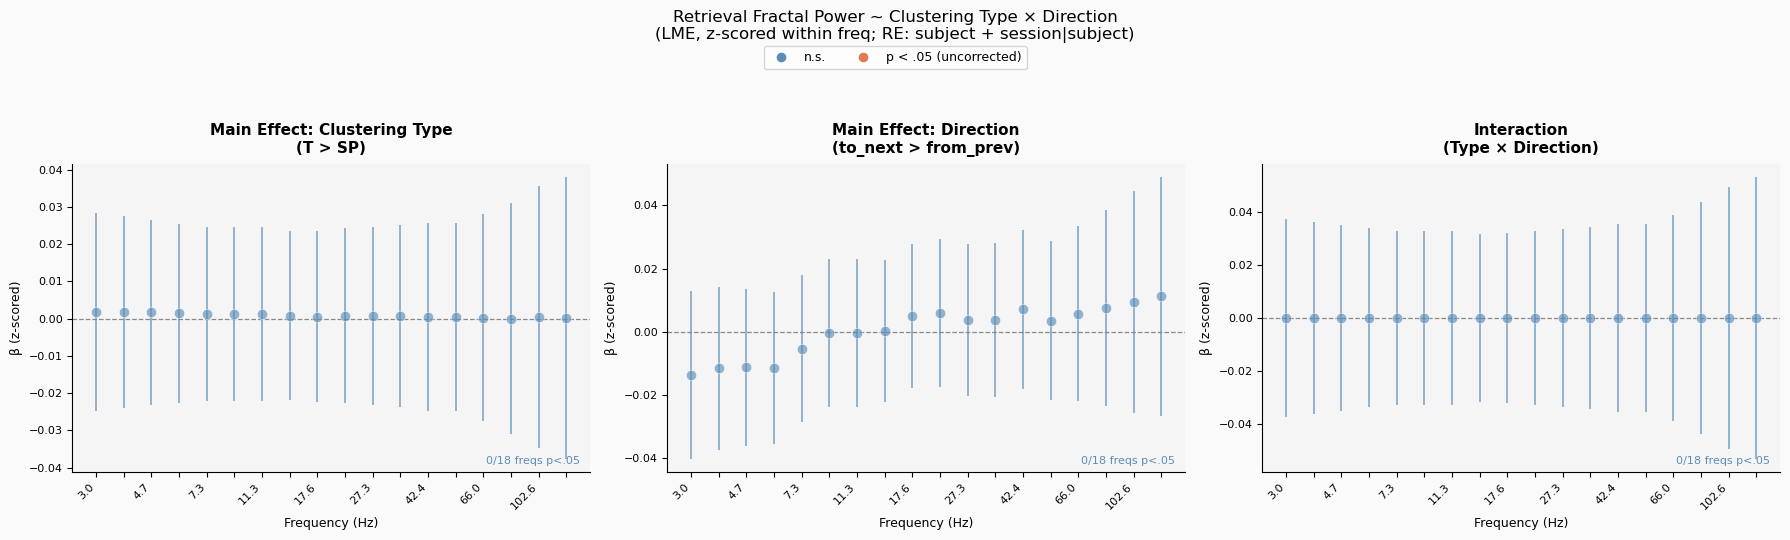

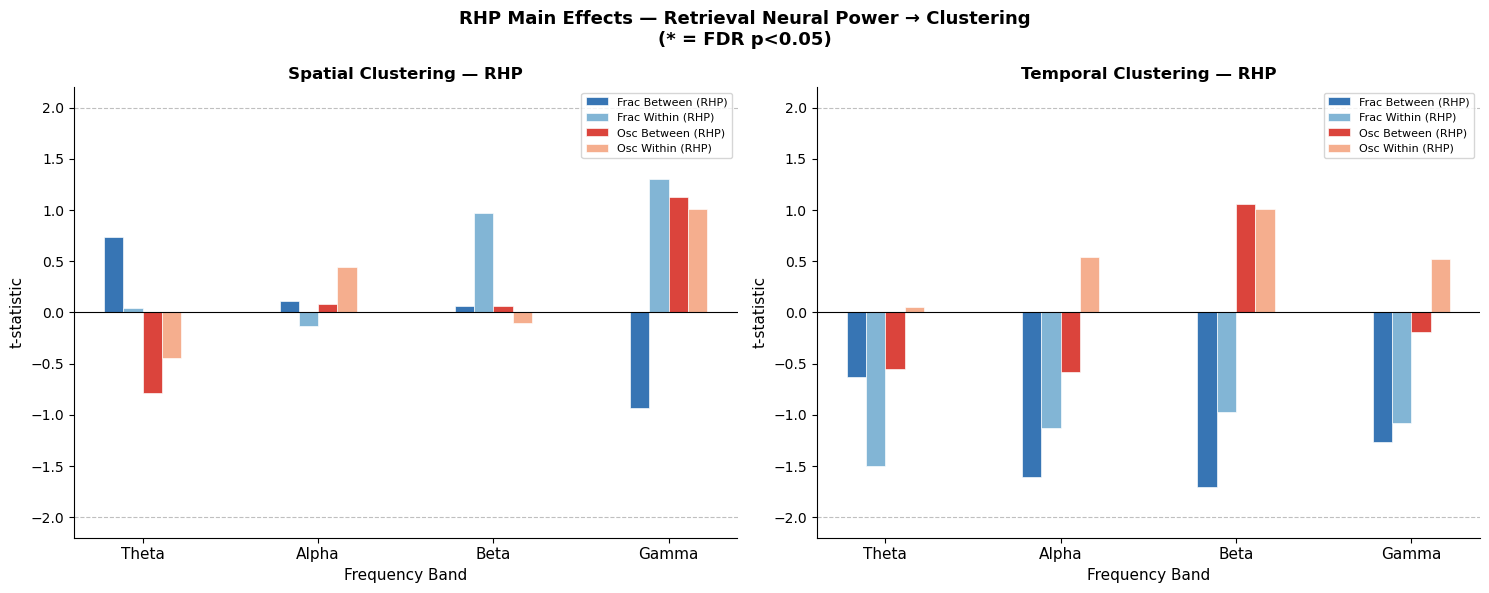

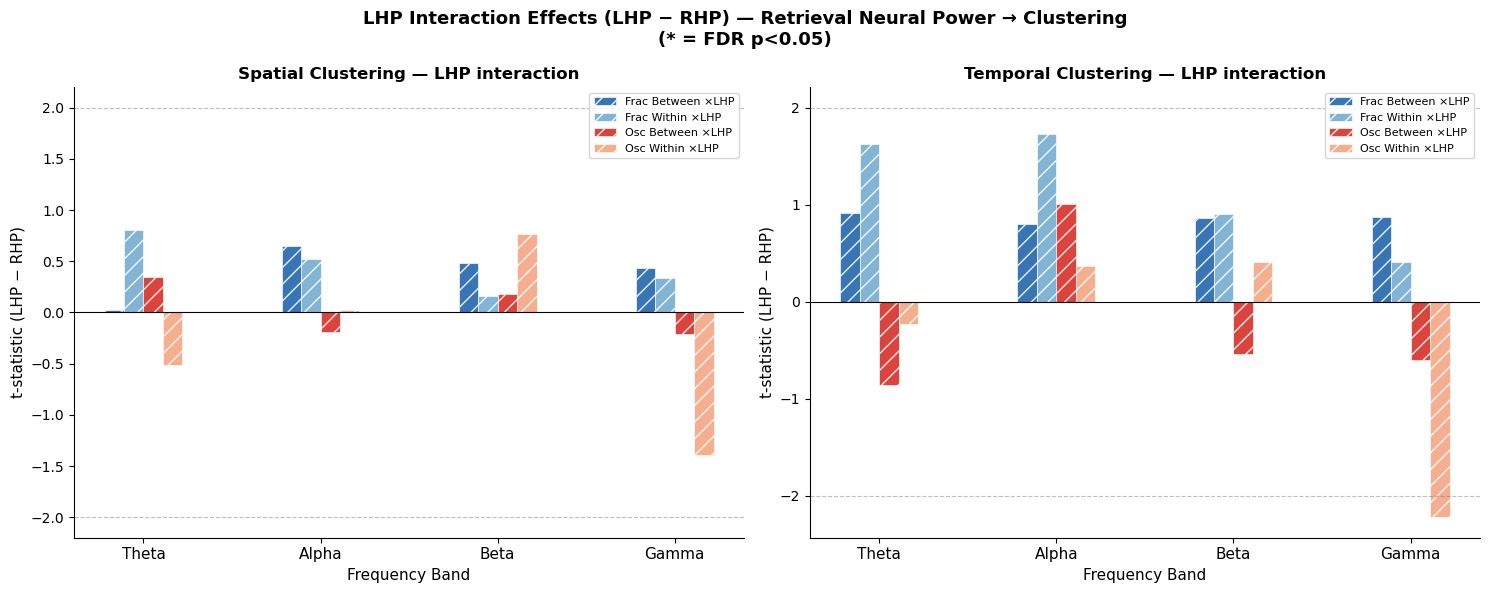

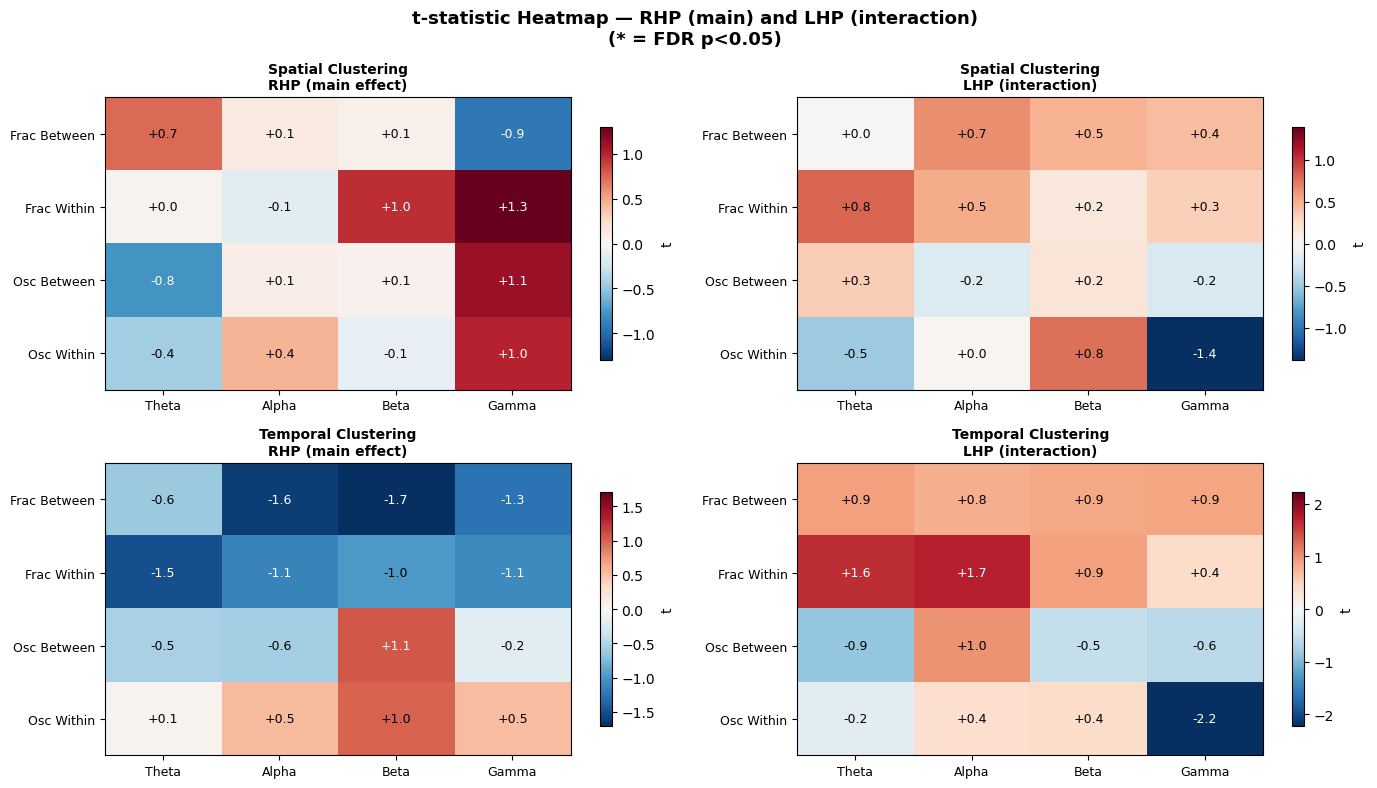

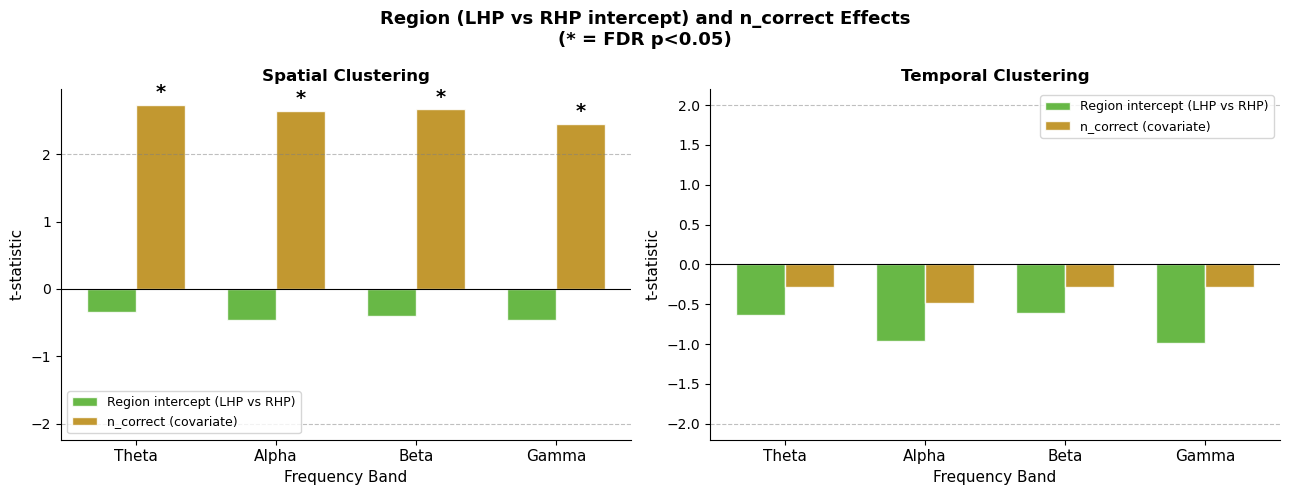


DONE


In [17]:
"""
Frequency Band Analysis — Retrieval Phase
==========================================
Single model per band × DV containing BOTH fractal and oscillatory components,
with left/right hippocampus as a factor and n_correct as a covariate.

Model (per band × DV):
  DV ~ frac_between + frac_within + osc_between + osc_within
       + region + n_correct
       + (1 | subject) + (0 + C(subj_session) | subject)

Between/within decomposition (Curran & Bauer, 2011):
  *_between = subject mean of predictor  (trait-level)
  *_within  = trial deviation from mean  (state-level)

FDR correction applied across bands (4 tests per predictor term).

DVs:
  SP_clustering_from_prev
  T_clustering_from_prev

Bands:
  theta  2–5 Hz
  alpha  5–12 Hz
  beta  12–40 Hz
  gamma 40+ Hz
"""

import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product as iproduct

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

DATA_FILE = 'ALL_SUBJECTS_irasa_clean.csv'

BANDS = {
    'theta': (2,   5),
    'alpha': (5,  12),
    'beta' : (12, 40),
    'gamma': (40, np.inf),
}
BAND_ORDER = ['theta', 'alpha', 'beta', 'gamma']

DVS   = ['SP_clustering_from_prev', 'T_clustering_from_prev']
DV_LABELS = {
    'SP_clustering_from_prev': 'Spatial Clustering',
    'T_clustering_from_prev' : 'Temporal Clustering',
}
PHASE = 'retrieval'
COMPS = ['frac', 'osc']

MIN_OBS = 20

NEURAL_COLS = [f'{PHASE}_{comp}_ssl' for comp in COMPS]

# ============================================================================
# LOAD & CLEAN
# ============================================================================

df = pd.read_csv(DATA_FILE)
df.replace(-999, np.nan, inplace=True)

print(f"Loaded {len(df):,} rows | {df['subject'].nunique()} subjects")
print(f"Regions: {sorted(df['region'].unique())}")
print(f"Freq range: {df['freq_hz'].min():.1f}–{df['freq_hz'].max():.1f} Hz\n")

# ── n_correct: unique recalled words per subject × session × trial ──────────
n_corr_map = (
    df.groupby(['subject', 'session', 'trial'])['recalled_word']
    .transform('nunique')
)
df['n_correct'] = n_corr_map

# ── band assignment ──────────────────────────────────────────────────────────
def assign_band(freq):
    for band, (lo, hi) in BANDS.items():
        if lo <= freq < hi:
            return band
    return None

df['band'] = df['freq_hz'].apply(assign_band)

# ── subj_session ─────────────────────────────────────────────────────────────
df['subj_session'] = df['subject'] + '_' + df['session'].astype(str)

# ── region as categorical (RHP = reference) ──────────────────────────────────
df['region'] = pd.Categorical(df['region'], categories=['RHP', 'LHP'])

# ============================================================================
# BAND-AVERAGE (per subject × session × trial × recalled_word × region × band)
# ============================================================================

GROUP_KEYS = ['subject', 'session', 'trial', 'recalled_word', 'region', 'band']

agg_dict = {col: 'mean' for col in NEURAL_COLS if col in df.columns}
agg_dict['n_correct'] = 'first'
agg_dict.update({dv: 'first' for dv in DVS})

df_band = (
    df.dropna(subset=['band'])
    .groupby(GROUP_KEYS, as_index=False, observed=True)
    .agg(agg_dict)
)
df_band['subj_session'] = df_band['subject'] + '_' + df_band['session'].astype(str)

print(f"Band-averaged dataframe: {len(df_band):,} rows\n")

# ============================================================================
# BETWEEN / WITHIN DECOMPOSITION
# ── computed within each band × region cell so the subject mean is
#    hemisphere-specific and does not conflate LHP and RHP variance ──────────
# ============================================================================

for comp in COMPS:
    col = f'{PHASE}_{comp}_ssl'
    df_band[f'{col}_between'] = np.nan
    df_band[f'{col}_within']  = np.nan

    for band in BAND_ORDER:
        for region in df_band['region'].cat.categories:
            mask = (df_band['band'] == band) & (df_band['region'] == region)
            sub  = df_band.loc[mask, ['subject', col]].copy()
            if sub[col].isna().all():
                continue
            # Subject mean is now specific to this hemisphere × band cell
            subj_mean = sub.groupby('subject')[col].transform('mean')
            df_band.loc[mask, f'{col}_between'] = subj_mean.values
            df_band.loc[mask, f'{col}_within']  = (sub[col] - subj_mean).values

print("Between/within decomposition done (region-specific).\n")

# ============================================================================
# LMM — both components in one model, region as factor with interactions,
#        n_correct covariate
#
# Model formula:
#   DV ~ region
#        + frac_between + frac_between:region
#        + frac_within  + frac_within:region
#        + osc_between  + osc_between:region
#        + osc_within   + osc_within:region
#        + n_correct
#        + (1|subject) + (0 + C(subj_session)|subject)
#
# This allows each neural predictor to have a DIFFERENT slope for LHP vs RHP.
# Main effect = RHP slope (reference); interaction = LHP - RHP difference.
# ============================================================================

def run_lmm(data, dv, frac_b, frac_w, osc_b, osc_w):
    # Statsmodels interaction term names
    keys = [
        'frac_between',              'frac_between:region[T.LHP]',
        'frac_within',               'frac_within:region[T.LHP]',
        'osc_between',               'osc_between:region[T.LHP]',
        'osc_within',                'osc_within:region[T.LHP]',
        'region[T.LHP]', 'n_correct',
    ]

    base = {f't_{k}': np.nan for k in keys}
    base.update({f'p_{k}': np.nan for k in keys})
    base.update({f'coef_{k}': np.nan for k in keys})
    base.update({'n_obs': len(data), 'n_subjects': data['subject'].nunique(),
                 'converged': False, 'note': 'failed'})

    # Interactions written explicitly so statsmodels names them predictably
    formula = (
        f'{dv} ~ region'
        f' + {frac_b} + {frac_b}:region'
        f' + {frac_w} + {frac_w}:region'
        f' + {osc_b}  + {osc_b}:region'
        f' + {osc_w}  + {osc_w}:region'
        f' + n_correct'
    )

    # Statsmodels names the interaction as "predictor:region[T.LHP]"
    param_map = {
        frac_b:                      'frac_between',
        f'{frac_b}:region[T.LHP]':   'frac_between:region[T.LHP]',
        frac_w:                      'frac_within',
        f'{frac_w}:region[T.LHP]':   'frac_within:region[T.LHP]',
        osc_b:                       'osc_between',
        f'{osc_b}:region[T.LHP]':    'osc_between:region[T.LHP]',
        osc_w:                       'osc_within',
        f'{osc_w}:region[T.LHP]':    'osc_within:region[T.LHP]',
        'region[T.LHP]':             'region[T.LHP]',
        'n_correct':                 'n_correct',
    }

    for vc, note in [
        ({'subj_session': '0 + C(subj_session)'}, 'full_RE'),
        (None, 'simple_RE'),
    ]:
        try:
            kwargs = dict(formula=formula, data=data,
                          groups=data['subject'], re_formula='~1')
            if vc:
                kwargs['vc_formula'] = vc

            fit = smf.mixedlm(**kwargs).fit(method='powell', maxiter=1000, disp=False)

            result = base.copy()
            result['converged'] = bool(fit.converged)
            result['note']      = note

            for pname, key in param_map.items():
                # statsmodels may reorder terms in interaction names
                candidates = [pname, pname.replace(':region[T.LHP]', ':region[T.LHP]')]
                for c in candidates:
                    if c in fit.params.index:
                        result[f'coef_{key}'] = float(fit.params[c])
                        result[f't_{key}']    = float(fit.tvalues[c])
                        result[f'p_{key}']    = float(fit.pvalues[c])
                        break
            return result

        except Exception:
            continue

    return base


# ============================================================================
# MAIN LOOP
# ============================================================================

PRED_KEYS = [
    'frac_between',            'frac_between:region[T.LHP]',
    'frac_within',             'frac_within:region[T.LHP]',
    'osc_between',             'osc_between:region[T.LHP]',
    'osc_within',              'osc_within:region[T.LHP]',
    'region[T.LHP]', 'n_correct',
]

rows = []

for dv in DVS:
    print(f"\n{'=' * 70}")
    print(f"DV: {dv}")
    print(f"{'=' * 70}")

    for band in BAND_ORDER:
        sub = df_band[df_band['band'] == band].dropna(
            subset=NEURAL_COLS + [dv, 'n_correct']
        ).copy()

        frac_col = f'{PHASE}_frac_ssl'
        osc_col  = f'{PHASE}_osc_ssl'
        frac_b   = f'{frac_col}_between'
        frac_w   = f'{frac_col}_within'
        osc_b    = f'{osc_col}_between'
        osc_w    = f'{osc_col}_within'

        sub = sub.dropna(subset=[frac_b, frac_w, osc_b, osc_w])

        meta = {'dv': dv, 'band': band}

        if len(sub) < MIN_OBS or sub['subject'].nunique() < 3:
            row = meta.copy()
            row.update({f't_{k}': np.nan for k in PRED_KEYS})
            row.update({f'p_{k}': np.nan for k in PRED_KEYS})
            row.update({f'coef_{k}': np.nan for k in PRED_KEYS})
            row.update({'n_obs': len(sub), 'n_subjects': sub['subject'].nunique(),
                        'converged': False, 'note': 'skipped'})
            rows.append(row)
            print(f"  {band:6s}: SKIPPED (n={len(sub)}, subjects={sub['subject'].nunique()})")
            continue

        res = run_lmm(sub, dv, frac_b, frac_w, osc_b, osc_w)
        res.update(meta)
        rows.append(res)

        print(f"  {band:6s}: n={res['n_obs']:4d} | "
              f"frac_B(RHP) t={res['t_frac_between']:+.2f} | "
              f"frac_B×LHP t={res['t_frac_between:region[T.LHP]']:+.2f} | "
              f"frac_W(RHP) t={res['t_frac_within']:+.2f} | "
              f"frac_W×LHP t={res['t_frac_within:region[T.LHP]']:+.2f} | "
              f"RE={res['note']}")

results = pd.DataFrame(rows)

# ============================================================================
# FDR CORRECTION — across 4 bands per predictor term per DV
# ============================================================================

print("\nApplying FDR correction (across bands, per predictor × DV)...")

for dv in DVS:
    dv_mask = results['dv'] == dv
    for key in PRED_KEYS:
        p_col   = f'p_{key}'
        fdr_col = f'p_fdr_{key}'
        sig_col = f'sig_fdr_{key}'

        p_vals = results.loc[dv_mask, p_col].values

        # Only correct non-NaN p-values
        valid_mask = ~np.isnan(p_vals)
        fdr_p = np.full(len(p_vals), np.nan)

        if valid_mask.sum() >= 2:
            _, pvals_corrected, _, _ = multipletests(
                p_vals[valid_mask], alpha=0.05, method='fdr_bh'
            )
            fdr_p[valid_mask] = pvals_corrected

        results.loc[dv_mask, fdr_col] = fdr_p
        results.loc[dv_mask, sig_col] = fdr_p < 0.05

# Uncorrected sig flags too
for key in PRED_KEYS:
    results[f'sig_uncorr_{key}'] = results[f'p_{key}'] < 0.05

# ============================================================================
# PRINT FDR-CORRECTED SUMMARY
# ============================================================================

print("\n\n" + "=" * 110)
print("FDR-CORRECTED RESULTS")
print("  Main effect (RHP slope) | Interaction (LHP - RHP difference)")
print("=" * 110)

for dv in DVS:
    print(f"\n{'━' * 110}")
    print(f"  DV: {dv}")
    print(f"{'━' * 110}")

    dv_sub = results[results['dv'] == dv]

    print(f"  {'Band':<8} "
          f"{'frac_B(RHP)':>13} {'p_fdr':>7}  "
          f"{'frac_B×LHP':>12} {'p_fdr':>7}  "
          f"{'frac_W(RHP)':>13} {'p_fdr':>7}  "
          f"{'frac_W×LHP':>12} {'p_fdr':>7}  "
          f"{'osc_B(RHP)':>12} {'p_fdr':>7}  "
          f"{'osc_B×LHP':>11} {'p_fdr':>7}  "
          f"{'osc_W(RHP)':>12} {'p_fdr':>7}  "
          f"{'osc_W×LHP':>11} {'p_fdr':>7}")
    print("  " + "─" * 108)

    for band in BAND_ORDER:
        row = dv_sub[dv_sub['band'] == band]
        if row.empty:
            continue
        row = row.iloc[0]

        def fmt_t(k):
            v = row.get(f't_{k}', np.nan)
            s = '*' if row.get(f'sig_fdr_{k}', False) else ' '
            return f"{v:+.2f}{s}" if not np.isnan(float(v)) else " NaN "

        def fmt_p(k):
            v = row.get(f'p_fdr_{k}', np.nan)
            return f"{v:.3f}" if not np.isnan(float(v)) else " NaN"

        print(f"  {band:<8} "
              f"{fmt_t('frac_between'):>13} {fmt_p('frac_between'):>7}  "
              f"{fmt_t('frac_between:region[T.LHP]'):>12} {fmt_p('frac_between:region[T.LHP]'):>7}  "
              f"{fmt_t('frac_within'):>13} {fmt_p('frac_within'):>7}  "
              f"{fmt_t('frac_within:region[T.LHP]'):>12} {fmt_p('frac_within:region[T.LHP]'):>7}  "
              f"{fmt_t('osc_between'):>12} {fmt_p('osc_between'):>7}  "
              f"{fmt_t('osc_between:region[T.LHP]'):>11} {fmt_p('osc_between:region[T.LHP]'):>7}  "
              f"{fmt_t('osc_within'):>12} {fmt_p('osc_within'):>7}  "
              f"{fmt_t('osc_within:region[T.LHP]'):>11} {fmt_p('osc_within:region[T.LHP]'):>7}")

print("\n  * = FDR-corrected p < 0.05")
print("  (RHP) = main effect = slope for RHP (reference hemisphere)")
print("  ×LHP  = interaction = difference of LHP slope from RHP slope\n")

# ============================================================================
# PLOTTING
# ============================================================================

# Color scheme: blue family = fractal, red family = osc
# Solid = RHP main effect, hatched = LHP interaction
NEURAL_KEYS_RHP_MAIN = ['frac_between',  'frac_within',  'osc_between',  'osc_within']
NEURAL_KEYS_LHP_INT = [
    'frac_between:region[T.LHP]', 'frac_within:region[T.LHP]',
    'osc_between:region[T.LHP]',  'osc_within:region[T.LHP]',
]

COLORS = {
    'frac_between':                    '#2166ac',
    'frac_between:region[T.LHP]':      '#2166ac',
    'frac_within':                     '#74add1',
    'frac_within:region[T.LHP]':       '#74add1',
    'osc_between':                     '#d73027',
    'osc_between:region[T.LHP]':       '#d73027',
    'osc_within':                      '#f4a582',
    'osc_within:region[T.LHP]':        '#f4a582',
}
LABELS_RHP_MAIN = {
    'frac_between': 'Frac Between (RHP)',
    'frac_within' : 'Frac Within (RHP)',
    'osc_between' : 'Osc Between (RHP)',
    'osc_within'  : 'Osc Within (RHP)',
}
LABELS_LHP_INT = {
    'frac_between:region[T.LHP]': 'Frac Between ×LHP',
    'frac_within:region[T.LHP]' : 'Frac Within ×LHP',
    'osc_between:region[T.LHP]' : 'Osc Between ×LHP',
    'osc_within:region[T.LHP]'  : 'Osc Within ×LHP',
}

x     = np.arange(len(BAND_ORDER))
width = 0.11   # 8 bars per band

# ── Figure 1: LHP main effects ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
fig.suptitle('RHP Main Effects — Retrieval Neural Power → Clustering\n(* = FDR p<0.05)',
             fontsize=13, fontweight='bold')

for ax_idx, dv in enumerate(DVS):
    ax  = axes[ax_idx]
    sub = results[results['dv'] == dv].set_index('band').reindex(BAND_ORDER)
    offsets = np.linspace(-1.5 * width, 1.5 * width, 4)

    for ki, key in enumerate(NEURAL_KEYS_RHP_MAIN):
        t_vals = sub[f't_{key}'].values.astype(float)
        p_fdrs = sub[f'p_fdr_{key}'].values.astype(float)
        bars = ax.bar(x + offsets[ki], t_vals, width,
                      color=COLORS[key], label=LABELS_RHP_MAIN[key],
                      edgecolor='white', linewidth=0.5, alpha=0.9)
        for bi, (tv, pv) in enumerate(zip(t_vals, p_fdrs)):
            if not np.isnan(pv) and pv < 0.05:
                ax.text(x[bi] + offsets[ki], tv + (0.1 if tv >= 0 else -0.25),
                        '*', ha='center', fontsize=13, fontweight='bold')

    ax.axhline(0,    color='black', linewidth=0.8)
    ax.axhline( 2.0, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(-2.0, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([b.capitalize() for b in BAND_ORDER], fontsize=11)
    ax.set_xlabel('Frequency Band', fontsize=11)
    ax.set_ylabel('t-statistic', fontsize=11)
    ax.set_title(f'{DV_LABELS[dv]} — RHP', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Figure 2: RHP interaction effects ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
fig.suptitle('LHP Interaction Effects (LHP − RHP) — Retrieval Neural Power → Clustering\n(* = FDR p<0.05)',
             fontsize=13, fontweight='bold')

for ax_idx, dv in enumerate(DVS):
    ax  = axes[ax_idx]
    sub = results[results['dv'] == dv].set_index('band').reindex(BAND_ORDER)
    offsets = np.linspace(-1.5 * width, 1.5 * width, 4)

    for ki, key in enumerate(NEURAL_KEYS_LHP_INT):
        t_vals = sub[f't_{key}'].values.astype(float)
        p_fdrs = sub[f'p_fdr_{key}'].values.astype(float)
        bars = ax.bar(x + offsets[ki], t_vals, width,
                      color=COLORS[key], label=LABELS_LHP_INT[key],
                      edgecolor='white', linewidth=0.5, alpha=0.9,
                      hatch='//')
        for bi, (tv, pv) in enumerate(zip(t_vals, p_fdrs)):
            if not np.isnan(pv) and pv < 0.05:
                ax.text(x[bi] + offsets[ki], tv + (0.1 if tv >= 0 else -0.25),
                        '*', ha='center', fontsize=13, fontweight='bold')

    ax.axhline(0,    color='black', linewidth=0.8)
    ax.axhline( 2.0, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(-2.0, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([b.capitalize() for b in BAND_ORDER], fontsize=11)
    ax.set_xlabel('Frequency Band', fontsize=11)
    ax.set_ylabel('t-statistic (LHP − RHP)', fontsize=11)
    ax.set_title(f'{DV_LABELS[dv]} — LHP interaction', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Figure 3: heatmap — LHP and RHP side by side per DV ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('t-statistic Heatmap — RHP (main) and LHP (interaction)\n(* = FDR p<0.05)',
             fontsize=13, fontweight='bold')

ROW_LABELS = ['Frac Between', 'Frac Within', 'Osc Between', 'Osc Within']

for dv_idx, dv in enumerate(DVS):
    sub = results[results['dv'] == dv].set_index('band').reindex(BAND_ORDER)

    for hem_idx, (keys_list, hem_label) in enumerate([
        (NEURAL_KEYS_RHP_MAIN, 'RHP (main effect)'),
        (NEURAL_KEYS_LHP_INT, 'LHP (interaction)'),
    ]):
        ax = axes[dv_idx][hem_idx]
        mat = np.array([
            sub[f't_{k}'].values.astype(float) for k in keys_list
        ])
        sig_mat = np.array([
            sub[f'p_fdr_{k}'].values.astype(float) for k in keys_list
        ])
        vmax = np.nanmax(np.abs(mat)) if not np.all(np.isnan(mat)) else 1
        im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

        for ri in range(mat.shape[0]):
            for ci in range(mat.shape[1]):
                tv = mat[ri, ci]
                pv = sig_mat[ri, ci]
                marker = '*' if (not np.isnan(pv) and pv < 0.05) else ''
                if not np.isnan(tv):
                    ax.text(ci, ri, f'{tv:+.1f}{marker}',
                            ha='center', va='center', fontsize=9,
                            color='white' if abs(tv) > vmax * 0.6 else 'black')

        ax.set_xticks(range(len(BAND_ORDER)))
        ax.set_xticklabels([b.capitalize() for b in BAND_ORDER], fontsize=9)
        ax.set_yticks(range(len(ROW_LABELS)))
        ax.set_yticklabels(ROW_LABELS, fontsize=9)
        ax.set_title(f'{DV_LABELS[dv]}\n{hem_label}', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, label='t', shrink=0.8)

plt.tight_layout()
plt.show()

# ── Figure 4: region main effect and n_correct ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Region (LHP vs RHP intercept) and n_correct Effects\n(* = FDR p<0.05)',
             fontsize=13, fontweight='bold')

for ax_idx, dv in enumerate(DVS):
    ax  = axes[ax_idx]
    sub = results[results['dv'] == dv].set_index('band').reindex(BAND_ORDER)

    t_region   = sub['t_region[T.LHP]'].values.astype(float)
    t_ncorrect = sub['t_n_correct'].values.astype(float)
    p_region   = sub['p_fdr_region[T.LHP]'].values.astype(float)
    p_ncorrect = sub['p_fdr_n_correct'].values.astype(float)

    bw = 0.35
    ax.bar(x - bw/2, t_region,   bw, label='Region intercept (LHP vs RHP)',
           color='#4dac26', alpha=0.85, edgecolor='white')
    ax.bar(x + bw/2, t_ncorrect, bw, label='n_correct (covariate)',
           color='#b8860b', alpha=0.85, edgecolor='white')

    for bi in range(len(BAND_ORDER)):
        if not np.isnan(p_region[bi]) and p_region[bi] < 0.05:
            y = t_region[bi] + (0.1 if t_region[bi] >= 0 else -0.25)
            ax.text(x[bi] - bw/2, y, '*', ha='center', fontsize=14, fontweight='bold')
        if not np.isnan(p_ncorrect[bi]) and p_ncorrect[bi] < 0.05:
            y = t_ncorrect[bi] + (0.1 if t_ncorrect[bi] >= 0 else -0.25)
            ax.text(x[bi] + bw/2, y, '*', ha='center', fontsize=14, fontweight='bold')

    ax.axhline(0,    color='black', linewidth=0.8)
    ax.axhline( 2.0, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(-2.0, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([b.capitalize() for b in BAND_ORDER], fontsize=11)
    ax.set_xlabel('Frequency Band', fontsize=11)
    ax.set_ylabel('t-statistic', fontsize=11)
    ax.set_title(DV_LABELS[dv], fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)